# Consolidated unit-gate comparison

This notebook runs exactly three matched experiments for the difficult unit-selection case $p=6$, $H=5$, $H_{true}=2$. Each run uses $K_{flow}=4$ and 2000 total epochs: epochs 1--500 are representation warmup and epochs 501--2000 use selection. The returned endpoint is always the final epoch.

The hard model first consolidates the repeated unit indicator with $I_j^2=I_j$. The resulting single indicator is then relaxed once: ReLU, ReQU, or normalized ReQU. It is never implemented as two soft gates.

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

module_dir = next(
    path for path in [
        Path.cwd() / "Python",
        Path.cwd().parent / "Python",
        Path.cwd() / "upload",
        Path.cwd().parent / "upload",
        Path.cwd(),
    ]
    if (path / "model2.py").exists()
)
if str(module_dir.parent) not in sys.path:
    sys.path.insert(0, str(module_dir.parent))

package = module_dir.name
md = importlib.import_module(f"{package}.model2")
mcmc = importlib.import_module(f"{package}.bnn_mcmc")
sim = importlib.import_module(f"{package}.simfun")
tr = importlib.import_module(f"{package}.bnn_train")
ut = importlib.import_module(f"{package}.utils")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


device(type='cpu')

## Fixed design

- ReLU: $G(m)=m_+$
- ReQU: $G(m)=m_+^2$
- normalized ReQU: $G(m)=m_+^2/(1+m_+^2)$
- hard PIP in every case: $P(I_j=1)=P(u_j-t>0)$
- warmup likelihood: effective $G_j=1$ exactly; posterior samples used by $\log q$ and $\log p$ are unchanged

Warmup metrics involving selection are diagnostic only. The comparison table uses the final epoch.

In [2]:
seed = 124
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

run_cfg = {
    "mcmc_N": 2500,
    "mcmc_burnin": 500,
    "epochs": 2000,
    "selection_warmup_epochs": 500,
    "K_flow": 4,
    "lr": 3e-4,
    "R_train": 100,
    "R_eval": 300,
    "R_final": 1000,
    "eval_every": 250,
    "init_loc_jitter": 0.05,
}

architecture = {
    "input_dim": 6,
    "H": 5,
    "out_dim": 1,
    "repu_power": None,
    "linear_skip": False,
}

X, y, feature_true, unit_true, signal, truth = sim.simfun_grouped_bnn(
    n=240,
    p=6,
    active_features=(0, 3),
    n_true_units=2,
    fit_units=5,
    repu_power=None,
    sigma2=1.0,
    seed=seed,
    device=device,
)

permutation = np.random.default_rng(seed).permutation(X.shape[0])
indices = {
    "train": permutation[:144],
    "val": permutation[144:192],
    "test": permutation[192:],
}
splits = ut.split_data(X, y, indices, mode="tensor")
signal_splits = ut.split_data(X, signal, indices, mode="tensor")

print("unit-rank truth:", unit_true.detach().cpu().numpy())
display(pd.DataFrame(truth["teacher_units"]))

unit-rank truth: [1. 1. 0. 0. 0.]


,teacher_unit,feature,slope,breakpoint,bias,amplitude
0,0,0,1.236111,0.045640,0.056417,1.081308
1,1,3,-1.094998,0.045737,-0.050082,1.189073


In [3]:
gate_configs = [
    {
        "gate": "ReLU",
        "formula": "m_+",
        "gate_power": 1.0,
        "gate_tau": None,
    },
    {
        "gate": "ReQU",
        "formula": "m_+^2",
        "gate_power": 2.0,
        "gate_tau": None,
    },
    {
        "gate": "Normalized ReQU",
        "formula": "m_+^2 / (1 + m_+^2)",
        "gate_power": 2.0,
        "gate_tau": 1.0,
    },
]

display(pd.DataFrame(gate_configs))

,gate,formula,gate_power,gate_tau
0,ReLU,m_+,1.0,NaN
1,ReQU,m_+^2,2.0,NaN
2,Normalized ReQU,m_+^2 / (1 + m_+^2),2.0,1.0


## Three matched runs

Each relaxation gets its own exactly matched MCMC reference because changing $G$ changes the relaxed likelihood. The data split, random seed, MCMC budget, flow, warmup, and total epochs are otherwise identical.

In [4]:
results = {}
summary_rows = []
recovery_tables = []

for gate_cfg in gate_configs:
    gate_name = gate_cfg["gate"]
    gate_args = {
        "gate_power": gate_cfg["gate_power"],
        "gate_tau": gate_cfg["gate_tau"],
    }
    print(f"\n{'=' * 72}\n{gate_name}\n{'=' * 72}")

    mcmc_model = md.GroupedBNNVI(
        X=splits["X_train"],
        y=splits["y_train"],
        selection_mode="unit_group",
        family=truth["family"],
        sigma2=truth["sigma2"],
        init_sd=0.5,
        K_flow=0,
        flow_type="meanfield",
        **gate_args,
        **architecture,
    ).to(device)

    mcmc_start = time.perf_counter()
    mcmc_ref = mcmc.run_bnn_mcmc(
        model=mcmc_model,
        N=run_cfg["mcmc_N"],
        S_max=100,
        burnin=run_cfg["mcmc_burnin"],
        thin=1,
        seed=seed,
        print_every=250,
    )
    mcmc_runtime = time.perf_counter() - mcmc_start
    mcmc_xi = torch.as_tensor(
        mcmc_ref["xi_draws"],
        device=device,
        dtype=X.dtype,
    )

    vi_start = time.perf_counter()
    fit = tr.train_grouped_bnn(
        X_train=splits["X_train"],
        y_train=splits["y_train"],
        X_eval=splits["X_val"],
        signal_eval=signal_splits["y_val"],
        X_final=splits["X_test"],
        signal_final=signal_splits["y_test"],
        mcmc_decoder=mcmc_model.decoder,
        mcmc_xi=mcmc_xi,
        truth=truth,
        selection_mode="unit_group",
        family=truth["family"],
        sigma2=truth["sigma2"],
        init_sd=0.5,
        K_flow=run_cfg["K_flow"],
        flow_type="attention_affine",
        flow_hidden_units=64,
        flow_hidden_layers=2,
        scale_clip=1.5,
        flow_token_dim=32,
        flow_num_heads=4,
        flow_mask_seed=seed,
        epochs=run_cfg["epochs"],
        selection_warmup_epochs=run_cfg["selection_warmup_epochs"],
        lr=run_cfg["lr"],
        R_train=run_cfg["R_train"],
        R_eval=run_cfg["R_eval"],
        R_final=run_cfg["R_final"],
        eval_every=run_cfg["eval_every"],
        init_loc_jitter=run_cfg["init_loc_jitter"],
        endpoint="last",
        checkpoint_metric=None,
        seed=seed,
        **gate_args,
        **architecture,
    )
    vi_runtime = time.perf_counter() - vi_start

    summary = fit["final"]["summary"]
    recovery = fit["final"]["recovery_by_target"].sort_values("target")
    ranked_pip = recovery["rat_pip"].to_numpy()

    results[gate_name] = {
        "fit": fit,
        "mcmc_model": mcmc_model,
        "mcmc_ref": mcmc_ref,
        "mcmc_xi": mcmc_xi,
        "vi_runtime_sec": vi_runtime,
        "mcmc_runtime_sec": mcmc_runtime,
    }
    recovery_tables.append(recovery.assign(gate=gate_name))
    summary_rows.append({
        "gate": gate_name,
        "epochs": run_cfg["epochs"],
        "warmup": run_cfg["selection_warmup_epochs"],
        "PIP_RMSE_truth": summary["pip_rmse_truth"],
        "active_SKL": summary["true_active_skl"],
        "RaT_R2": summary["rat_signal_r2"],
        "ELBO": summary["elbo"],
        "runtime_min": vi_runtime / 60.0,
        "MCMC_runtime_min": mcmc_runtime / 60.0,
        "PIP_RMSE_MCMC": summary["pip_rmse_mcmc"],
        "zero_JS": summary["zero_js"],
        **{f"rank{i + 1}_PIP": value for i, value in enumerate(ranked_pip)},
    })


ReLU
mcmc_iter=00001 loglik=-372.578
mcmc_iter=00250 loglik=-200.526
mcmc_iter=00500 loglik=-209.079
mcmc_iter=00750 loglik=-202.397
mcmc_iter=01000 loglik=-201.221
mcmc_iter=01250 loglik=-199.701
mcmc_iter=01500 loglik=-198.569
mcmc_iter=01750 loglik=-204.144
mcmc_iter=02000 loglik=-206.965
mcmc_iter=02250 loglik=-200.413
mcmc_iter=02500 loglik=-200.332
epoch=0001 phase=repr   valR2=-0.9690
epoch=0250 phase=repr   valR2=0.9583
epoch=0500 phase=repr   valR2=0.9600
epoch=0750 phase=select valR2=0.9651 pipTruth=0.1548 activeSKL=5.5698
epoch=1000 phase=select valR2=0.9660 pipTruth=0.0119 activeSKL=1.9946
epoch=1250 phase=select valR2=0.9657 pipTruth=0.0119 activeSKL=1.9400
epoch=1500 phase=select valR2=0.9660 pipTruth=0.0135 activeSKL=1.6609
epoch=1750 phase=select valR2=0.9527 pipTruth=0.0015 activeSKL=1.1992
epoch=2000 phase=select valR2=0.9624 pipTruth=0.0119 activeSKL=0.5749

ReQU
mcmc_iter=00001 loglik=-379.404
mcmc_iter=00250 loglik=-204.585
mcmc_iter=00500 loglik=-204.363
mcmc_ite

In [5]:
summary_table = pd.DataFrame(summary_rows)
primary_columns = [
    "gate",
    "epochs",
    "warmup",
    "PIP_RMSE_truth",
    "active_SKL",
    "RaT_R2",
    "ELBO",
    "runtime_min",
    "rank1_PIP",
    "rank2_PIP",
    "rank3_PIP",
    "rank4_PIP",
    "rank5_PIP",
]
display(summary_table[primary_columns].round(4))

secondary_columns = [
    "gate",
    "PIP_RMSE_MCMC",
    "zero_JS",
    "MCMC_runtime_min",
]
display(summary_table[secondary_columns].round(4))

,gate,epochs,warmup,PIP_RMSE_truth,active_SKL,RaT_R2,ELBO,runtime_min,rank1_PIP,rank2_PIP,rank3_PIP,rank4_PIP,rank5_PIP
0,ReLU,2000,500,0.0148,0.7963,0.9505,-241.3886,5.1838,1.0,1.0,0.033,0.000,0.000
1,ReQU,2000,500,0.0435,1.3739,0.9498,-242.2123,2.3894,1.0,1.0,0.097,0.008,0.000
2,Normalized ReQU,2000,500,0.0905,0.3588,0.9497,-240.0995,2.4247,1.0,1.0,0.201,0.023,0.001


,gate,PIP_RMSE_MCMC,zero_JS,MCMC_runtime_min
0,ReLU,0.3275,0.1131,1.8589
1,ReQU,0.2385,0.0593,1.6975
2,Normalized ReQU,0.3256,0.1412,1.1062


In [6]:
recovery_table = pd.concat(recovery_tables, ignore_index=True)
display(
    recovery_table[[
        "gate",
        "label",
        "truth_pip",
        "rat_pip",
        "mcmc_pip",
        "conditional_slab_skl",
        "zero_mass_js",
    ]].round(4)
)

,gate,label,truth_pip,rat_pip,mcmc_pip,conditional_slab_skl,zero_mass_js
0,ReLU,unit_rank_1,1.0,1.000,1.0000,0.6892,NaN
1,ReLU,unit_rank_2,1.0,1.000,1.0000,0.9033,NaN
2,ReLU,unit_rank_3,0.0,0.033,0.7030,NaN,0.2812
3,ReLU,unit_rank_4,0.0,0.000,0.2905,NaN,0.1131
4,ReLU,unit_rank_5,0.0,0.000,0.0540,NaN,0.0191
5,ReQU,unit_rank_1,1.0,1.000,1.0000,1.5944,NaN
6,ReQU,unit_rank_2,1.0,1.000,1.0000,1.1535,NaN
7,ReQU,unit_rank_3,0.0,0.097,0.5950,NaN,0.1482
8,ReQU,unit_rank_4,0.0,0.008,0.1975,NaN,0.0593
9,ReQU,unit_rank_5,0.0,0.000,0.0220,NaN,0.0077


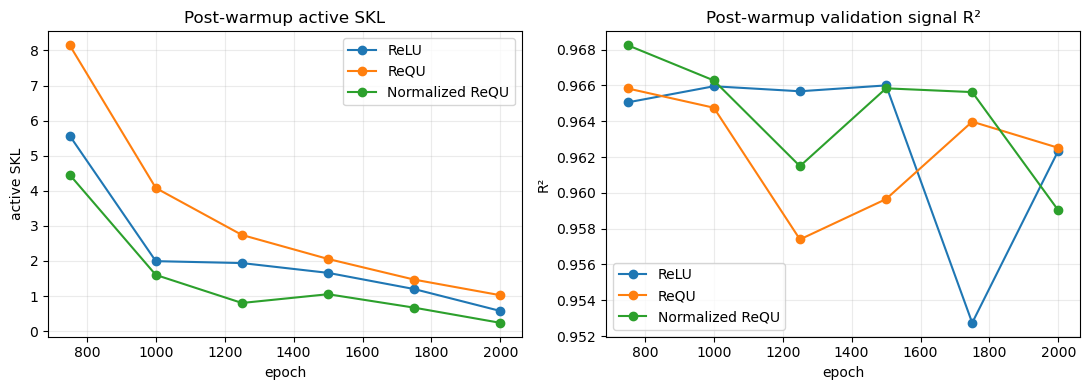

In [7]:
history = pd.concat(
    [item["fit"]["history"].assign(gate=gate) for gate, item in results.items()],
    ignore_index=True,
)
post_warmup = history[
    history["epoch"] > run_cfg["selection_warmup_epochs"]
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for gate_name, frame in post_warmup.groupby("gate", sort=False):
    axes[0].plot(frame["epoch"], frame["true_active_skl"], marker="o", label=gate_name)
    axes[1].plot(frame["epoch"], frame["val_signal_r2"], marker="o", label=gate_name)

axes[0].set(title="Post-warmup active SKL", xlabel="epoch", ylabel="active SKL")
axes[1].set(title="Post-warmup validation signal R²", xlabel="epoch", ylabel="R²")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()


ReLU
joint-active draws: RaT=1000, MCMC=2000
joint-active probability: RaT=1.0000, MCMC=1.0000
conditional joint SKL: 1.8354


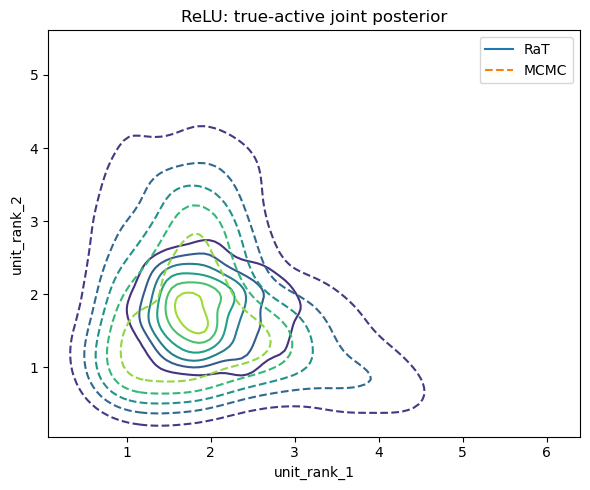


ReQU
joint-active draws: RaT=1000, MCMC=2000
joint-active probability: RaT=1.0000, MCMC=1.0000
conditional joint SKL: 3.1899


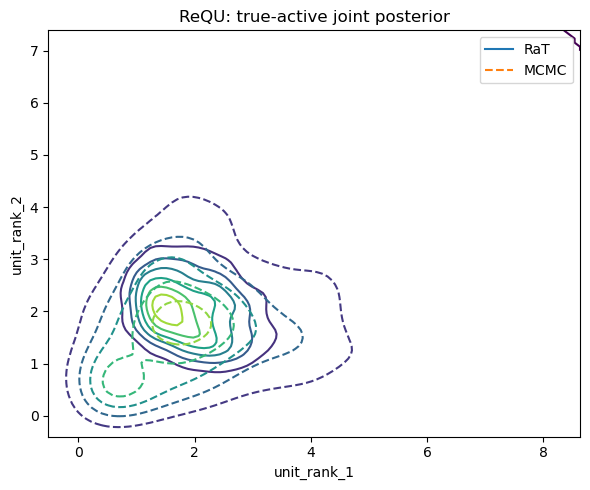


Normalized ReQU
joint-active draws: RaT=1000, MCMC=2000
joint-active probability: RaT=1.0000, MCMC=1.0000
conditional joint SKL: 1.0401


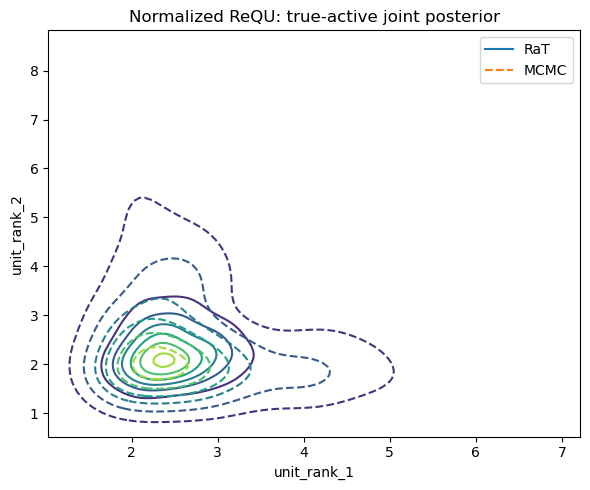

In [9]:
# ============================================================
# True-active joint posterior density
# ReLU / ReQU / Normalized ReQU
# ============================================================
import Python.metric as me

for gate_name in [
    "ReLU",
    "ReQU",
    "Normalized ReQU",
]:
    item = results[gate_name]
    fit = item["fit"]

    print("\n" + "=" * 72)
    print(gate_name)
    print("=" * 72)

    fig, ax = me.plot_true_active_joint_density(
        rat_decoder=fit["model"].decoder,
        rat_xi=fit["final"]["xi"],

        mcmc_decoder=item["mcmc_model"].decoder,
        mcmc_xi=item["mcmc_xi"],

        truth=truth,

        min_draws=50,
        n_grid=100,
    )

    if fig is not None:
        ax.set_title(
            f"{gate_name}: true-active joint posterior"
        )
        plt.show()